<a href="https://colab.research.google.com/github/anabiarochar/Mestrado_MLG/blob/main/scikit_MLP_AnaRibeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Árvores de Decisão, Seleção de Atributos e de Modelos**

---





# Caso: **Pima Indians Diabetes**

https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv






In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# URL do dataset (Repositório UCI via GitHub)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Definindo os nomes das colunas em Português
colunas = [
    'gravidez', 'glicose', 'pressao', 'espessura_triceps',
    'insulina', 'imc', 'historico_familiar', 'idade', 'resultado'
]

# Carregando o arquivo
df = pd.read_csv(url, names=colunas)

print("Primeiras linhas do dataset:")
print(df.head())



Primeiras linhas do dataset:
   gravidez  glicose  pressao  espessura_triceps  insulina   imc  \
0         6      148       72                 35         0  33.6   
1         1       85       66                 29         0  26.6   
2         8      183       64                  0         0  23.3   
3         1       89       66                 23        94  28.1   
4         0      137       40                 35       168  43.1   

   historico_familiar  idade  resultado  
0               0.627     50          1  
1               0.351     31          0  
2               0.672     32          1  
3               0.167     21          0  
4               2.288     33          1  


In [ ]:
# Substituindo 0 por NaN em colunas onde o valor zero é fisicamente impossível
cols_com_zeros = ['glicose', 'pressao', 'espessura_triceps', 'insulina', 'imc']
df[cols_com_zeros] = df[cols_com_zeros].replace(0, np.nan)

for col in cols_com_zeros:
    df[col] = df[col].fillna(df[col].median())


# Exercício 1. Label Encode e Conjuntos de Treinamento e Teste


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('resultado', axis=1)
y = df['resultado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# MLP

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

mlp = MLPClassifier(batch_size=5, max_iter=1000, hidden_layer_sizes=(10, 10), random_state=1234)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

print("Accuracy on training set: {:.2f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(mlp.score(X_test, y_test)))

Accuracy on training set: 0.80
Accuracy on test set: 0.73


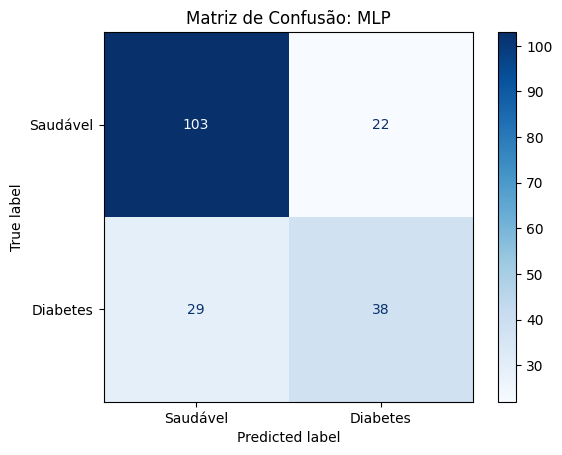


Relatório de Classificação para MLP:

              precision    recall  f1-score   support

    Saudável       0.78      0.82      0.80       125
    Diabetes       0.63      0.57      0.60        67

    accuracy                           0.73       192
   macro avg       0.71      0.70      0.70       192
weighted avg       0.73      0.73      0.73       192



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def show_results(model_name):
    # Using y_test and y_pred from the most recent model (MLP)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saudável', 'Diabetes'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusão: {model_name}')
    plt.show()

    print(f"\nRelatório de Classificação para {model_name}:\n")
    print(classification_report(y_test, y_pred, target_names=['Saudável', 'Diabetes']))

show_results('MLP')